# Test 11: Адаптация Chaos Activation для структурированных данных

**Проблема:** V4 (sin(8x)+0.5·tanh(4x)) даёт 0% мёртвых нейронов, но проигрывает по качеству реконструкции на MNIST (0.067 vs 0.011 у TopK+ReLU).

**Гипотеза:** Адаптация активации под структурированные данные может сохранить 0% мёртвых нейронов и улучшить качество реконструкции.

**3 подхода:**
- A: Низкая частота sin — a ∈ {1, 2, 4, 8}, фиксированные w=0.5, b=4
- B: Обучаемые коэффициенты — a, w, b как trainable параметры
- C: Гибрид — chaos activation только в латентном слое, ReLU в остальных

**Данные:** MNIST, N=5 прогонов, 10 эпох

**Метрики:** val_loss, dead neurons, variance

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Базовые компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_chaos_activation(a=8.0, w=0.5, b=4.0):
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


class TrainableChaosActivation(layers.Layer):
    """Chaos activation с обучаемыми коэффициентами a, w, b"""
    def __init__(self, a_init=8.0, w_init=0.5, b_init=4.0, **kwargs):
        super().__init__(**kwargs)
        self.a_init = a_init
        self.w_init = w_init
        self.b_init = b_init

    def build(self, input_shape):
        self.a = self.add_weight(name='a', shape=(), initializer=keras.initializers.Constant(self.a_init), trainable=True)
        self.w = self.add_weight(name='w', shape=(), initializer=keras.initializers.Constant(self.w_init), trainable=True)
        self.b = self.add_weight(name='b', shape=(), initializer=keras.initializers.Constant(self.b_init), trainable=True)
        super().build(input_shape)

    def call(self, x):
        return tf.sin(self.a * x) + self.w * tf.tanh(self.b * x)

    def get_config(self):
        config = super().get_config()
        config.update({'a_init': self.a_init, 'w_init': self.w_init, 'b_init': self.b_init})
        return config


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    zero_mask = np.abs(latents) < threshold
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
        'sparsity': float(np.mean(zero_mask)),
    }


print("Core components ready.")

Core components ready.


In [3]:
# === Архитектуры ===

def build_v4_chaos(image_size=(28, 28), latent_dim=128, k_active=32, a=8.0, w=0.5, b=4.0):
    """Подход A: V4 с настраиваемой частотой"""
    act = make_chaos_activation(a=a, w=w, b=b)
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_trainable_chaos(image_size=(28, 28), latent_dim=128, k_active=32):
    """Подход B: обучаемые коэффициенты"""
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = TrainableChaosActivation(name='chaos_1')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = TrainableChaosActivation(name='chaos_2')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = TrainableChaosActivation(name='chaos_3')(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_hybrid(image_size=(28, 28), latent_dim=128, k_active=32):
    """Подход C: ReLU везде, chaos только в латентном слое"""
    chaos_act = make_chaos_activation(a=8.0, w=0.5, b=4.0)
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu(image_size=(28, 28), latent_dim=128, k_active=32):
    """Baseline: TopK+ReLU"""
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("Architectures defined.")

Architectures defined.


In [4]:
# === Данные ===
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"MNIST train: {x_train.shape}, test: {x_test.shape}")

MNIST train: (60000, 28, 28, 1), test: (10000, 28, 28, 1)


In [5]:
# === Подход A: Частота sin ===
print("=" * 70)
print("ПОДХОД A: Влияние частоты sin на структурированных данных")
print("=" * 70)

NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 128

frequencies = [1, 2, 4, 8]
freq_results = {}

for a in frequencies:
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = build_v4_chaos(latent_dim=128, k_active=32, a=float(a))
        history = ae.fit(
            x_train, x_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(x_test, x_test),
            verbose=0
        )
        s = analyze_latent(enc, x_test)
        s['val_loss'] = history.history['val_loss'][-1]
        runs.append(s)

        print(f"  a={a:<3} run {run+1}/{NUM_RUNS}: "
              f"loss={s['val_loss']:.4f}, "
              f"dead={s['dead_neurons']}/128, "
              f"var={s['mean_variance']:.4f}")

        del ae, enc
        keras.backend.clear_session()

    freq_results[a] = runs
    print()

print("Подход A завершён.")

ПОДХОД A: Влияние частоты sin на структурированных данных


2026-04-06 14:23:17.741676: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 14:23:17.741700: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 14:23:17.741704: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 14:23:17.741717: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 14:23:17.741725: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-06 14:23:18.357124: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  a=1   run 1/5: loss=0.0091, dead=0/128, var=0.1673
  a=1   run 2/5: loss=0.0095, dead=0/128, var=0.1623
  a=1   run 3/5: loss=0.0093, dead=0/128, var=0.1675
  a=1   run 4/5: loss=0.0093, dead=0/128, var=0.1689
  a=1   run 5/5: loss=0.0092, dead=0/128, var=0.1660

  a=2   run 1/5: loss=0.0364, dead=0/128, var=0.4539
  a=2   run 2/5: loss=0.0377, dead=0/128, var=0.4720
  a=2   run 3/5: loss=0.0393, dead=0/128, var=0.4754
  a=2   run 4/5: loss=0.0424, dead=0/128, var=0.4943
  a=2   run 5/5: loss=0.0418, dead=0/128, var=0.4825

  a=4   run 1/5: loss=0.0666, dead=0/128, var=0.4468
  a=4   run 2/5: loss=0.0653, dead=0/128, var=0.4567
  a=4   run 3/5: loss=0.0659, dead=0/128, var=0.4518
  a=4   run 4/5: loss=0.0663, dead=0/128, var=0.4432
  a=4   run 5/5: loss=0.0658, dead=0/128, var=0.4489

  a=8   run 1/5: loss=0.0670, dead=0/128, var=0.4056
  a=8   run 2/5: loss=0.0673, dead=0/128, var=0.4047
  a=8   run 3/5: loss=0.0668, dead=0/128, var=0.4107
  a=8   run 4/5: loss=0.0667, dead=0/128, v

In [6]:
# === Подход B: Обучаемые коэффициенты ===
print("=" * 70)
print("ПОДХОД B: Обучаемые коэффициенты a, w, b")
print("=" * 70)

trainable_results = []
learned_params_log = []

for run in range(NUM_RUNS):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_trainable_chaos(latent_dim=128, k_active=32)
    history = ae.fit(
        x_train, x_train,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(x_test, x_test),
        verbose=0
    )
    s = analyze_latent(enc, x_test)
    s['val_loss'] = history.history['val_loss'][-1]
    trainable_results.append(s)

    # Извлекаем выученные коэффициенты
    learned = {}
    for layer in ae.layers:
        if isinstance(layer, TrainableChaosActivation):
            learned[layer.name] = {
                'a': float(layer.a.numpy()),
                'w': float(layer.w.numpy()),
                'b': float(layer.b.numpy()),
            }
    learned_params_log.append(learned)

    params_str = " | ".join(
        f"{name}: a={p['a']:.2f} w={p['w']:.2f} b={p['b']:.2f}"
        for name, p in learned.items()
    )
    print(f"  run {run+1}/{NUM_RUNS}: "
          f"loss={s['val_loss']:.4f}, "
          f"dead={s['dead_neurons']}/128, "
          f"var={s['mean_variance']:.4f}")
    print(f"    Выученные: {params_str}")

    del ae, enc
    keras.backend.clear_session()

print("\nПодход B завершён.")

ПОДХОД B: Обучаемые коэффициенты a, w, b
  run 1/5: loss=0.0636, dead=0/128, var=0.8694
    Выученные: chaos_1: a=8.02 w=0.54 b=4.00 | chaos_2: a=7.98 w=1.24 b=2.68 | chaos_3: a=8.11 w=1.24 b=1.42
  run 2/5: loss=0.0637, dead=0/128, var=0.8138
    Выученные: chaos_1: a=8.10 w=0.58 b=3.93 | chaos_2: a=7.96 w=1.17 b=2.83 | chaos_3: a=8.08 w=1.24 b=1.44
  run 3/5: loss=0.0621, dead=0/128, var=0.9036
    Выученные: chaos_1: a=7.88 w=0.60 b=4.04 | chaos_2: a=7.99 w=1.28 b=2.71 | chaos_3: a=8.19 w=1.29 b=1.42
  run 4/5: loss=0.0638, dead=0/128, var=0.8062
    Выученные: chaos_1: a=7.96 w=0.64 b=4.02 | chaos_2: a=8.02 w=1.17 b=2.86 | chaos_3: a=8.16 w=1.24 b=1.42
  run 5/5: loss=0.0628, dead=0/128, var=0.8755
    Выученные: chaos_1: a=8.01 w=0.56 b=4.01 | chaos_2: a=7.94 w=1.24 b=2.69 | chaos_3: a=8.18 w=1.27 b=1.38

Подход B завершён.


In [7]:
# === Подход C: Гибрид (ReLU + chaos только в латенте) ===
print("=" * 70)
print("ПОДХОД C: Гибрид — ReLU везде, chaos только в латентном слое")
print("=" * 70)

hybrid_results = []

for run in range(NUM_RUNS):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_hybrid(latent_dim=128, k_active=32)
    history = ae.fit(
        x_train, x_train,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(x_test, x_test),
        verbose=0
    )
    s = analyze_latent(enc, x_test)
    s['val_loss'] = history.history['val_loss'][-1]
    hybrid_results.append(s)

    print(f"  run {run+1}/{NUM_RUNS}: "
          f"loss={s['val_loss']:.4f}, "
          f"dead={s['dead_neurons']}/128, "
          f"var={s['mean_variance']:.4f}")

    del ae, enc
    keras.backend.clear_session()

print("\nПодход C завершён.")

ПОДХОД C: Гибрид — ReLU везде, chaos только в латентном слое
  run 1/5: loss=0.0583, dead=0/128, var=0.3968
  run 2/5: loss=0.0645, dead=0/128, var=0.3749
  run 3/5: loss=0.0636, dead=0/128, var=0.3780
  run 4/5: loss=0.0587, dead=0/128, var=0.3929
  run 5/5: loss=0.0576, dead=0/128, var=0.3970

Подход C завершён.


In [8]:
# === Baseline: TopK+ReLU ===
print("=" * 70)
print("BASELINE: TopK+ReLU")
print("=" * 70)

baseline_results = []

for run in range(NUM_RUNS):
    np.random.seed(run)
    tf.random.set_seed(run)

    ae, enc = build_topk_relu(latent_dim=128, k_active=32)
    history = ae.fit(
        x_train, x_train,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(x_test, x_test),
        verbose=0
    )
    s = analyze_latent(enc, x_test)
    s['val_loss'] = history.history['val_loss'][-1]
    baseline_results.append(s)

    print(f"  run {run+1}/{NUM_RUNS}: "
          f"loss={s['val_loss']:.4f}, "
          f"dead={s['dead_neurons']}/128, "
          f"var={s['mean_variance']:.4f}")

    del ae, enc
    keras.backend.clear_session()

print("\nBaseline завершён.")

BASELINE: TopK+ReLU
  run 1/5: loss=0.0124, dead=67/128, var=7031.9150
  run 2/5: loss=0.0115, dead=63/128, var=4504.3921
  run 3/5: loss=0.0118, dead=65/128, var=5445.6855
  run 4/5: loss=0.0117, dead=64/128, var=4621.2100
  run 5/5: loss=0.0113, dead=60/128, var=3869.2942

Baseline завершён.


In [9]:
# === Сводная таблица ===
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА")
print("=" * 70)
print(f"{'Метод':<30} {'Val Loss':>14} {'Dead':>12} {'Variance':>14}")
print('-' * 75)

all_methods = {}

# Подход A
for a in frequencies:
    name = f'A: Chaos a={a}'
    runs = freq_results[a]
    all_methods[name] = runs
    l = [r['val_loss'] for r in runs]
    d = [r['dead_neurons'] for r in runs]
    v = [r['mean_variance'] for r in runs]
    print(f"{name:<30} {np.mean(l):.4f} ± {np.std(l):.4f} "
          f"{np.mean(d):>5.1f} ± {np.std(d):.1f} "
          f"{np.mean(v):.4f} ± {np.std(v):.4f}")

# Подход B
name = 'B: Trainable Chaos'
all_methods[name] = trainable_results
l = [r['val_loss'] for r in trainable_results]
d = [r['dead_neurons'] for r in trainable_results]
v = [r['mean_variance'] for r in trainable_results]
print(f"{name:<30} {np.mean(l):.4f} ± {np.std(l):.4f} "
      f"{np.mean(d):>5.1f} ± {np.std(d):.1f} "
      f"{np.mean(v):.4f} ± {np.std(v):.4f}")

# Подход C
name = 'C: Hybrid (ReLU+Chaos)'
all_methods[name] = hybrid_results
l = [r['val_loss'] for r in hybrid_results]
d = [r['dead_neurons'] for r in hybrid_results]
v = [r['mean_variance'] for r in hybrid_results]
print(f"{name:<30} {np.mean(l):.4f} ± {np.std(l):.4f} "
      f"{np.mean(d):>5.1f} ± {np.std(d):.1f} "
      f"{np.mean(v):.4f} ± {np.std(v):.4f}")

# Baseline
name = 'Baseline: TopK+ReLU'
all_methods[name] = baseline_results
l = [r['val_loss'] for r in baseline_results]
d = [r['dead_neurons'] for r in baseline_results]
v = [r['mean_variance'] for r in baseline_results]
print(f"{name:<30} {np.mean(l):.4f} ± {np.std(l):.4f} "
      f"{np.mean(d):>5.1f} ± {np.std(d):.1f} "
      f"{np.mean(v):.4f} ± {np.std(v):.4f}")


СВОДНАЯ ТАБЛИЦА
Метод                                Val Loss         Dead       Variance
---------------------------------------------------------------------------
A: Chaos a=1                   0.0093 ± 0.0001   0.0 ± 0.0 0.1664 ± 0.0023
A: Chaos a=2                   0.0395 ± 0.0023   0.0 ± 0.0 0.4756 ± 0.0133
A: Chaos a=4                   0.0660 ± 0.0004   0.0 ± 0.0 0.4495 ± 0.0046
A: Chaos a=8                   0.0670 ± 0.0002   0.0 ± 0.0 0.4086 ± 0.0031
B: Trainable Chaos             0.0632 ± 0.0006   0.0 ± 0.0 0.8537 ± 0.0376
C: Hybrid (ReLU+Chaos)         0.0605 ± 0.0029   0.0 ± 0.0 0.3879 ± 0.0095
Baseline: TopK+ReLU            0.0117 ± 0.0004  63.8 ± 2.3 5094.4994 ± 1090.8958


In [10]:
# === Выученные коэффициенты (Подход B) ===
print("\nВыученные коэффициенты (Подход B):")
print(f"{'Слой':<10} {'a (init=8)':>12} {'w (init=0.5)':>14} {'b (init=4)':>12}")
print('-' * 52)

for layer_name in ['chaos_1', 'chaos_2', 'chaos_3']:
    a_vals = [lp[layer_name]['a'] for lp in learned_params_log if layer_name in lp]
    w_vals = [lp[layer_name]['w'] for lp in learned_params_log if layer_name in lp]
    b_vals = [lp[layer_name]['b'] for lp in learned_params_log if layer_name in lp]
    if a_vals:
        print(f"{layer_name:<10} "
              f"{np.mean(a_vals):>6.2f} ± {np.std(a_vals):.2f} "
              f"{np.mean(w_vals):>8.2f} ± {np.std(w_vals):.2f} "
              f"{np.mean(b_vals):>6.2f} ± {np.std(b_vals):.2f}")


Выученные коэффициенты (Подход B):
Слой         a (init=8)   w (init=0.5)   b (init=4)
----------------------------------------------------
chaos_1      8.00 ± 0.07     0.58 ± 0.03   4.00 ± 0.04
chaos_2      7.98 ± 0.03     1.22 ± 0.04   2.75 ± 0.07
chaos_3      8.15 ± 0.04     1.26 ± 0.02   1.42 ± 0.02


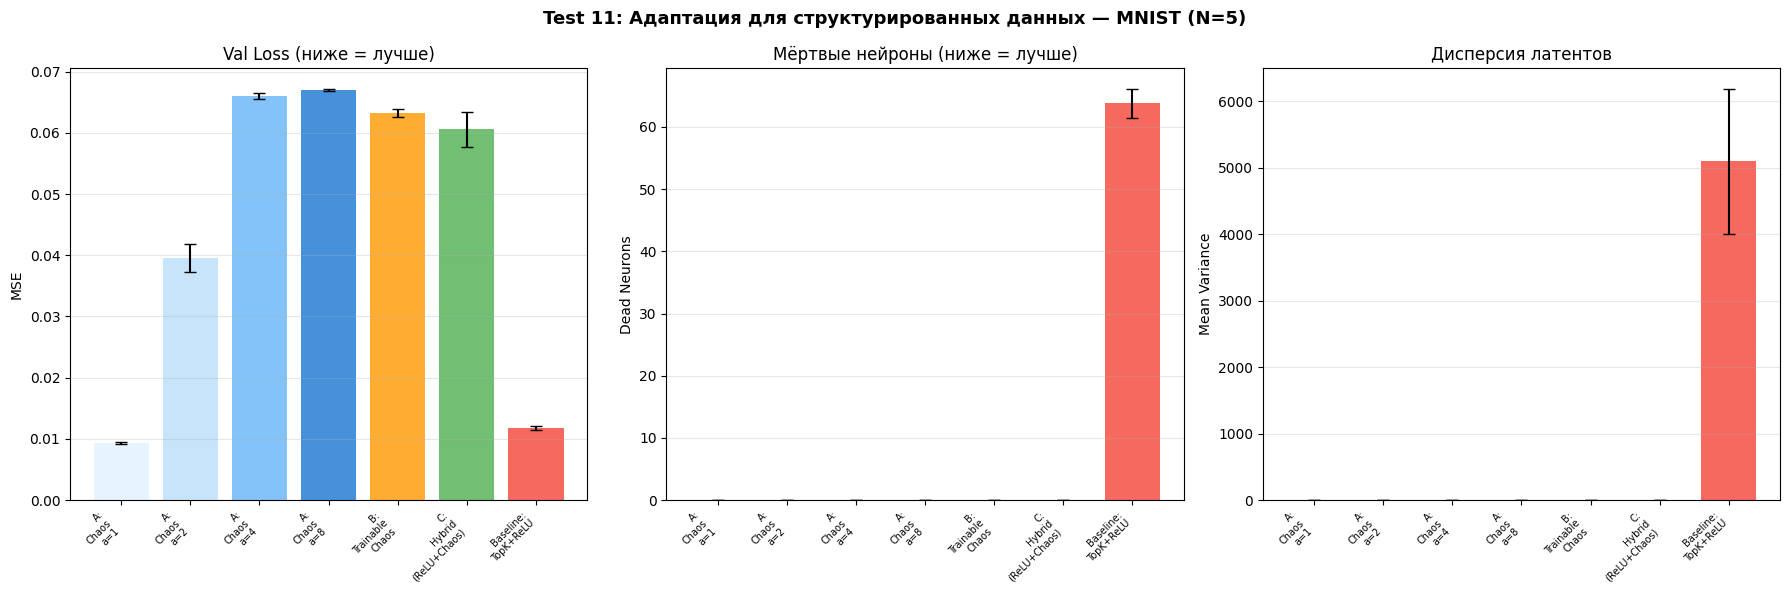

Saved: images/structured_data_adaptation.png


In [11]:
# === Визуализация ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

method_names = list(all_methods.keys())
x_pos = np.arange(len(method_names))
colors = ['#E3F2FD', '#BBDEFB', '#64B5F6', '#1976D2',  # A: от светлого к тёмному
          '#FF9800',  # B: оранжевый
          '#4CAF50',  # C: зелёный
          '#F44336']  # Baseline: красный

# Val Loss
means = [np.mean([r['val_loss'] for r in all_methods[m]]) for m in method_names]
stds = [np.std([r['val_loss'] for r in all_methods[m]]) for m in method_names]
axes[0].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([n.replace(' ', '\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[0].set_ylabel('MSE')
axes[0].set_title('Val Loss (ниже = лучше)')
axes[0].grid(True, alpha=0.3, axis='y')

# Dead Neurons
means = [np.mean([r['dead_neurons'] for r in all_methods[m]]) for m in method_names]
stds = [np.std([r['dead_neurons'] for r in all_methods[m]]) for m in method_names]
axes[1].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[1].set_ylabel('Dead Neurons')
axes[1].set_title('Мёртвые нейроны (ниже = лучше)')
axes[1].grid(True, alpha=0.3, axis='y')

# Variance
means = [np.mean([r['mean_variance'] for r in all_methods[m]]) for m in method_names]
stds = [np.std([r['mean_variance'] for r in all_methods[m]]) for m in method_names]
axes[2].bar(x_pos, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([n.replace(' ', '\n') for n in method_names], fontsize=7, rotation=45, ha='right')
axes[2].set_ylabel('Mean Variance')
axes[2].set_title('Дисперсия латентов')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Test 11: Адаптация для структурированных данных — MNIST (N={NUM_RUNS})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/structured_data_adaptation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/structured_data_adaptation.png")

Обучение моделей для визуализации...
  A: Chaos a=1 trained.
  A: Chaos a=8 trained.
  C: Hybrid trained.
  Baseline: TopK+ReLU trained.


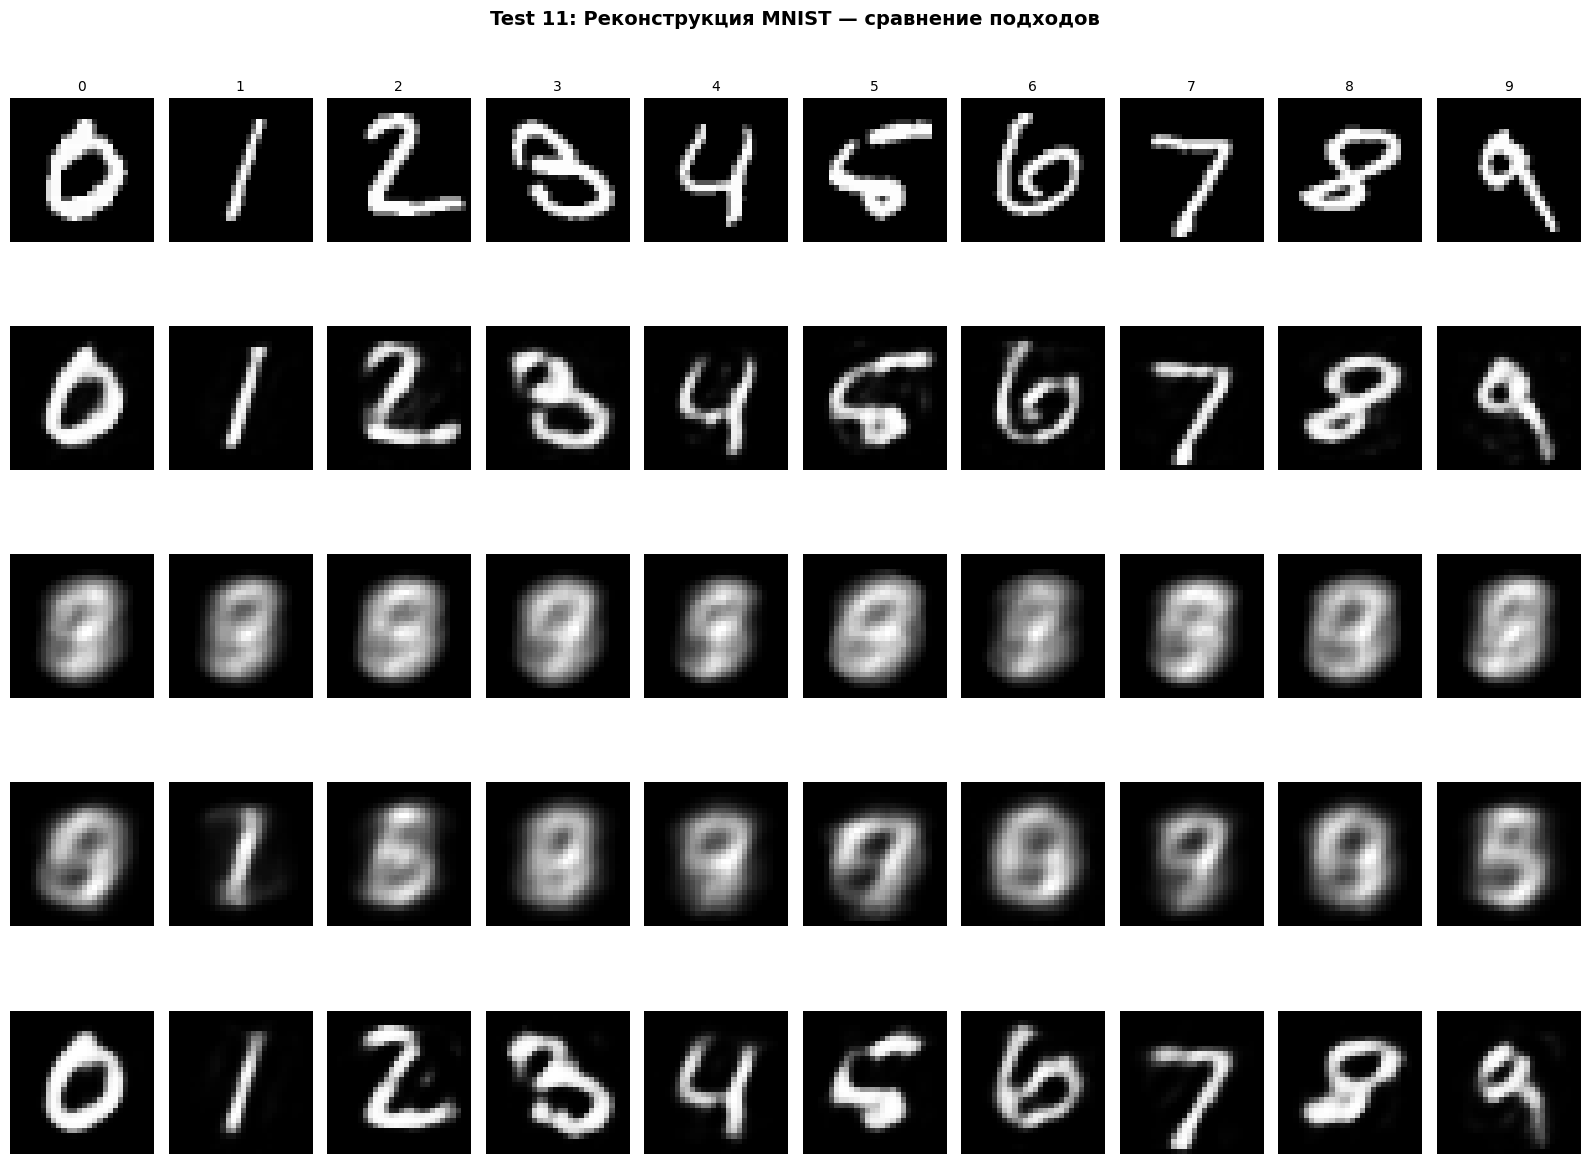

Done.


In [12]:
# === Визуализация реконструкций MNIST ===
print("Обучение моделей для визуализации...")

viz_configs = {
    'A: Chaos a=1': lambda: build_v4_chaos(latent_dim=128, k_active=32, a=1.0),
    'A: Chaos a=8': lambda: build_v4_chaos(latent_dim=128, k_active=32, a=8.0),
    'C: Hybrid': lambda: build_hybrid(latent_dim=128, k_active=32),
    'Baseline: TopK+ReLU': lambda: build_topk_relu(latent_dim=128, k_active=32),
}

viz_models = {}
for name, builder in viz_configs.items():
    np.random.seed(0)
    tf.random.set_seed(0)
    ae, enc = builder()
    ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    viz_models[name] = (ae, enc)
    print(f"  {name} trained.")

# Выбираем по одному примеру каждой цифры
sample_indices = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test[sample_indices]

n_models = len(viz_configs)
fig, axes = plt.subplots(n_models + 1, 10, figsize=(16, 2.5 * (n_models + 1)))

# Оригиналы
for i in range(10):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i), fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=70)

# Реконструкции
for row, (name, (ae, enc)) in enumerate(viz_models.items(), 1):
    recons = ae.predict(samples, verbose=0)
    s = analyze_latent(enc, x_test)
    for i in range(10):
        axes[row, i].imshow(recons[i, :, :, 0], cmap='gray')
        axes[row, i].axis('off')
    label = f"{name}\nloss={s['mean_variance']:.3f} dead={s['dead_neurons']}"
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=70)

plt.suptitle('Test 11: Реконструкция MNIST — сравнение подходов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cleanup
for ae, enc in viz_models.values():
    del ae, enc
keras.backend.clear_session()
print("Done.")

In [13]:
# === Сохранение результатов ===
save_data = {
    'experiment': 'structured_data_adaptation',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'MNIST',
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': 128,
        'k_active': 32,
    },
    'approach_A_frequencies': {
        str(a): runs for a, runs in freq_results.items()
    },
    'approach_B_trainable': trainable_results,
    'approach_B_learned_params': learned_params_log,
    'approach_C_hybrid': hybrid_results,
    'baseline_topk_relu': baseline_results,
}

json_path = f'../jsons/structured_adaptation_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/structured_adaptation_20260406_151921.json
